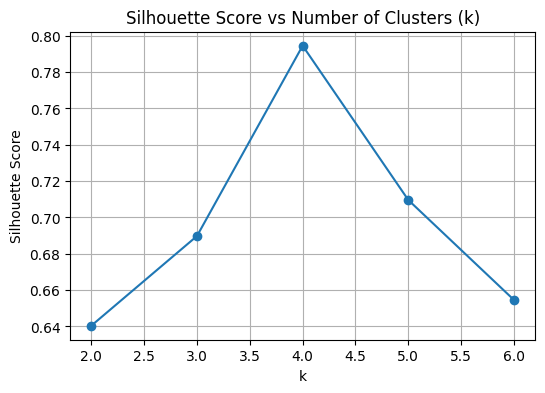

Best k based on silhouette score: 4


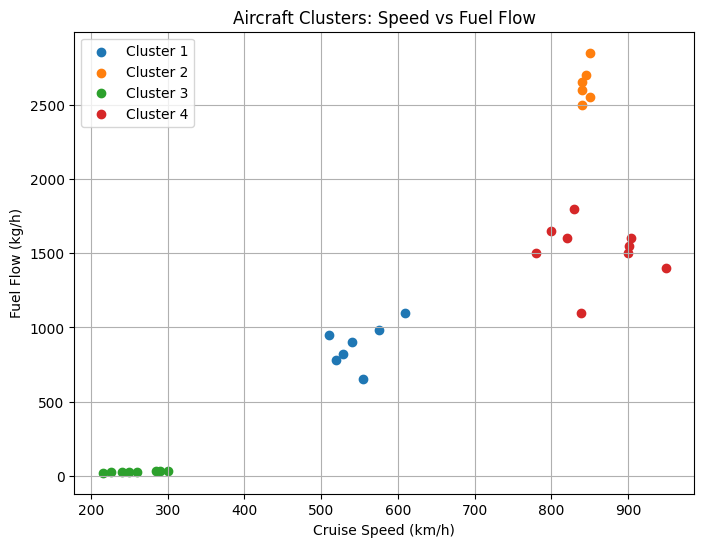

In [62]:
#Question 1

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

data = pd.read_csv("aircraft_performance.csv")

X = data[["Speed_kmh", "FuelFlow_kgph"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

silhouette_scores = []
k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters (k)")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

best_k = k_values[silhouette_scores.index(max(silhouette_scores))]
print(f"Best k based on silhouette score: {best_k}")

final_kmeans = KMeans(n_clusters=best_k, random_state=42)
data["Cluster"] = final_kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
for cluster in range(best_k):
    cluster_points = data[data["Cluster"] == cluster]
    plt.scatter(cluster_points["Speed_kmh"], cluster_points["FuelFlow_kgph"], label=f"Cluster {cluster+1}")

plt.title("Aircraft Clusters: Speed vs Fuel Flow")
plt.xlabel("Cruise Speed (km/h)")
plt.ylabel("Fuel Flow (kg/h)")
plt.legend()
plt.grid(True)
plt.show()



Four clusters obtain the highest silhouette score. Cluster 1 has mid range speed with mid to low fuel flow, this is likely some sort of turbofan commuter plane based on the speed and relative fuel efficiency. Cluster 2 is high fuel flow and high speed, this is likely some sort of large jet powered aircraft which flies fast and still burns lots of fuel, potentially military. Cluster 3 is both low fuel flow and low speed which would correpsond to a small prop plane for example like a Cesna. Cluster 4 is high speed and middle range fuel flow, which could be a commerical jet due to the increased fuel efficiency or higher performance airaft.

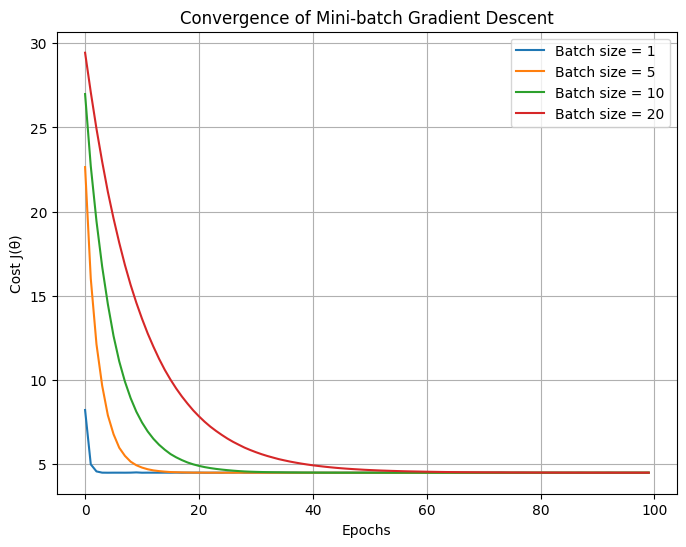

Predicted house price for population 160,000: $150860.29


In [63]:
#Question 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("housing_prices.txt", header=None, names=["Population", "Price"])

X_raw = data["Population"].values.reshape(-1, 1)  # raw population
y = data["Price"].values.reshape(-1, 1)           # target

X_mean = np.mean(X_raw)
X_std = np.std(X_raw)
X_scaled = (X_raw - X_mean) / X_std

X = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]  # shape (m,2)

def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    error = predictions - y
    return (1/(2*m)) * np.sum(error ** 2)

def minibatch_gradient_descent(X, y, theta, alpha, epochs, batch_size):
    m = len(y)
    cost_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            gradients = (1/len(X_batch)) * X_batch.T.dot(X_batch.dot(theta) - y_batch)
            theta = theta - alpha * gradients

        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

batch_sizes = [1, 5, 10, 20]
alpha = 0.01
epochs = 100

plt.figure(figsize=(8,6))

for batch_size in batch_sizes:
    theta_init = np.zeros((2,1))
    theta, cost_history = minibatch_gradient_descent(X, y, theta_init, alpha, epochs, batch_size)
    plt.plot(range(epochs), cost_history, label=f"Batch size = {batch_size}")

plt.xlabel("Epochs")
plt.ylabel("Cost J(θ)")
plt.title("Convergence of Mini-batch Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()


theta_init = np.zeros((2,1))
theta, cost_history = minibatch_gradient_descent(X, y, theta_init, alpha, epochs, batch_size=20)


population = 16.0
pop_scaled = (population - X_mean) / X_std
X_new = np.array([[1, pop_scaled]])
predicted_price = X_new.dot(theta)

print(f"Predicted house price for population 160,000: ${predicted_price[0,0] * 10000:.2f}")


When the batch size is equal to one there is more noise present but convergence is faster.

In [64]:
#Question 3

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)

X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.feature_selection import RFE

log_reg = LogisticRegression(max_iter=5000, solver='liblinear')

rfe = RFE(estimator=log_reg, n_features_to_select=2)
rfe.fit(X_train_scaled, y_train)

selected_features = X_train.columns[rfe.support_]
print("Selected Features:", selected_features)

X_train_sel = X_train_scaled[:, rfe.support_]
X_test_sel = X_test_scaled[:, rfe.support_]

log_reg.fit(X_train_sel, y_train)

y_pred = log_reg.predict(X_test_sel)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Selected Features: Index(['worst area', 'worst concave points'], dtype='object')
Accuracy: 0.9415204678362573
Precision: 0.944954128440367
Recall: 0.9626168224299065
F1 Score: 0.9537037037037037

Confusion Matrix:
 [[ 58   6]
 [  4 103]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.91      0.92        64
           1       0.94      0.96      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


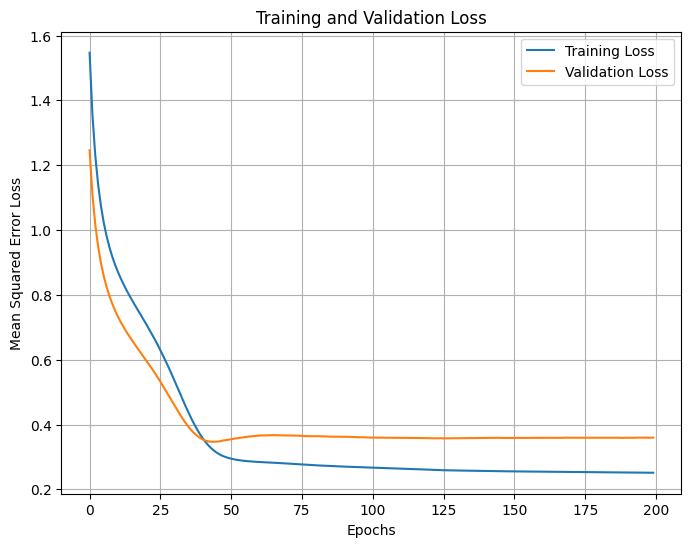

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted house price for population 165,000: 162342.09
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
MAE: 2.14, MSE: 11.20, RMSE: 3.35, R2: 0.59


In [65]:
#Question 4

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("housing_prices.txt", header=None, names=["Population", "Price"])

X = data["Population"].values.reshape(-1, 1)
y = data["Price"].values.reshape(-1, 1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)

y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

model = Sequential([
    Dense(2, activation='relu', input_shape=(1,)),  # Single hidden layer with 2 neurons
    Dense(1)  # Output layer for regression
])

optimizer = SGD(learning_rate=0.001)

model.compile(optimizer=optimizer, loss='mean_squared_error')

history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=200,   # Adjust epochs for convergence
    batch_size=1, # Stochastic Gradient Descent
    verbose=0
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

population_input = np.array([[16.5]])
population_scaled = scaler_X.transform(population_input)

pred_scaled = model.predict(population_scaled)
pred_price = scaler_y.inverse_transform(pred_scaled)

print(f"Predicted house price for population 165,000: {pred_price[0,0]*10000:.2f}")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_val_pred_scaled = model.predict(X_val_scaled)
y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled)

mae = mean_absolute_error(y_val, y_val_pred)
mse = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_val_pred)

print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")


Both training and validation data start with high loss and decrease quickly before stabilizing, with training loss falling slightly below validation loss. Increasing the number of epochs is observed to increase convergence and reduce average MSE. If the learning rate is increased, more noise is observed in both losses.